# Part 2: Getting familiar with eABF 

(last updated: Tuesday, Nov. 9th, 14:50)

We first make sure that graphics display nicely.

In [1]:
from IPython.core.display import  HTML
# Jupyter display settings
display(HTML("<style>.container { width:90% !important; }</style>"))

We start by importing all required packages.

In [1]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
import torch 
## Some imports for plotting an animation.
from matplotlib import animation
from matplotlib.animation import FuncAnimation
## notebook --> inline for those using google colab.
#%matplotlib notebook 

## Free energies

We first re-define potential function as in Part 1. 

In [2]:
def g(a):
    """Gaussian function

    :param a: float, real value
    :return: float, g(a)
    """
    return np.exp(- a ** 2)

class TripleWellPotential:
    """Class to gather methods related to the potential function"""
    def __init__(self, beta):
        """Initialise potential function class

        :param beta: float,  inverse temperature = 1 / (k_B * T)
        """
        self.beta = beta
        self.dim = 2
        self.Z = None
        self.set_Z()
        
    def V(self, X):
        """Potential fuction

        :param X: np.array, Position  vector (x,y), ndim = 1, shape = (2,)
        :return: V: float, potential energy value
        """
        assert(type(X) == np.ndarray)
        assert(X.ndim == 1)
        assert(X.shape[0] == 2)
        x = X[0]
        y = X[1]
        u = g(x) * (g(y - 1/3) - g(y - 5/3))
        v = g(y) * (g(x - 1) + g(x + 1))
        V = 3 * u - 5 * v + 0.2 * (x ** 4) + 0.2 * ((y - 1/3) ** 4)
        return V
    
    def dV_x(self, x, y):
        """
        :param x: float, x coordinate
        :param y: float, y coordinate

        :return: dVx: float, derivative of the potential with respect to x
        """
        u = g(x) * (g(y - 1/3) - g(y - 5/3))
        a = g(y) * ((x - 1)*g(x - 1) + (x + 1) * g(x + 1))
        dVx = -6 * x * u + 10 * a + 0.8 * (x ** 3)
        return dVx
    
    def dV_y(self, x, y):
        """
        :param x: float, x coordinate
        :param y: float, y coordinate

        :return: dVy: float, derivative of the potential with respect to y
        """
        u = g(x) * ((y - 1/3) * g(y - 1/3) - (y - 5/3) * g(y - 5/3))
        b = g(y) * (g(x - 1) + g(x + 1))
        dVy = -6 * u + 10 * y * b + 0.8 * ((y - 1/3) ** 3)
        return dVy
    
    def nabla_V(self, X):
        """Gradient of potential fuction

        :param X: np.array, Position  vector (x,y), ndim = 1, shape = (2,)
        :return: grad(X): np.array, gradient of position  vector (x,y), ndim = 1, shape = (2,)
        """
        assert(type(X) == np.ndarray)
        assert(X.ndim == 1)
        assert(X.shape[0] == 2)
        return np.array([self.dV_x(X[0], X[1]), self.dV_y(X[0], X[1])])
    
    #--- we add three methods to cumpute free energy ---
    def boltz_weight(self, y, x):  # mind the order of the arguments! Needed in this order for numerical quadrature
        """Compute unnormalized weight in the Botzmann distribution

        :param x: float, x coordinate
        :param y: float, y coordinate

        :return: unnormalized Blotzmann weight
        """
        X = np.array([x, y])
        return np.exp(-self.beta * self.V(X))
    
    def set_Z(self):
        """Compute partition function 
        """
        self.Z, _ = integrate.dblquad(self.boltz_weight, -5, 5, -5, 5)

    def Fx(self, x):
        """Free energy for the value x of the reaction coordinate xi(x,y) = x

        :param x: float, x coordinate

        :return: float, mean force
        """
        Z_x, _ = integrate.quad(self.boltz_weight, -5, 5, args=(x))
        return - np.log(Z_x/self.Z) / self.beta


We next compute the free energy for the reaction coordinate $\xi(x,y) = x$ and various values of $\beta$, by a numerical quadrature (possible here since the system is sufficiently low dimensional).

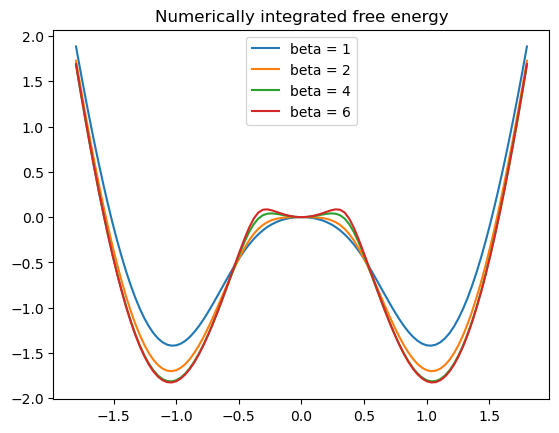

In [3]:
pot1 = TripleWellPotential(1)
pot2 = TripleWellPotential(2)
pot4 = TripleWellPotential(4)
pot6 = TripleWellPotential(6)
#--- compute the free energies on a 1D grid in x ---
x_range = np.linspace(-1.8, 1.8, 100)
Fx1_range = np.zeros(100)
Fx2_range = np.zeros(100)
Fx4_range = np.zeros(100)
Fx6_range = np.zeros(100)
for i,x  in enumerate(x_range):
    Fx1_range[i] = pot1.Fx(x)
    Fx2_range[i] = pot2.Fx(x)
    Fx4_range[i] = pot4.Fx(x)
    Fx6_range[i] = pot6.Fx(x)
#--- Shift all profiles to set the 0 of free energy at x = 0 ---
Fx1_range = Fx1_range - (Fx1_range[49] + Fx1_range[50])/2
Fx2_range = Fx2_range - (Fx2_range[49] + Fx2_range[50])/2
Fx4_range = Fx4_range - (Fx4_range[49] + Fx4_range[50])/2
Fx6_range = Fx6_range - (Fx6_range[49] + Fx6_range[50])/2
#--- plot the result ---
plt.title('Numerically integrated free energy')
plt.plot(x_range, Fx1_range, label='beta = 1')
plt.plot(x_range, Fx2_range, label='beta = 2')
plt.plot(x_range, Fx4_range, label='beta = 4')
plt.plot(x_range, Fx6_range, label='beta = 6')
plt.legend(loc='upper center')
plt.show()

**Question 1.** The free energy profiles are clearly different when $\beta$ changes. Can you explain it? Would it be reasonable that the reaction coordinate also depends on the temperature?

## eABF in action 

We now want to compare the above reference free energy profiles with those obtained from an eABF simulation, in order to understand the choice of parameters for eABF. We define to this end an eABF class, which among its attributes the potential, the eABF parameter $\kappa$ and the reaction coordinate $\xi$. 

In [4]:
class eABF():
    
    def __init__(self, 
                 pot, 
                 k, 
                 Xi=lambda x:x[0], 
                 grad_Xi=lambda x : np.array([1., 0.]), 
                 eXi_interval=[-1.5, 1.5],
                 Xi_interval=None,
                 n_grids=200):
        """

        :param pot: object containing potential, must have a method nabla_V to compute the gradient of the potential
        :param k: float, value kappa for the harmonic restraint
        :param Xi: Reaction coordinate function (only 1D supported), default 
        :param grad_Xi: Gradient of the reaction coordinate function, default 
        :param eXi_interval: Range of the reaction coordinate for the extended system on which the bias is applied
        :param n_grids: Number of bins in the interval on which the RC for extended system is considered
        """        
        # initialization of (extended) potential and related parameters
        self.beta = pot.beta
        self.nabla_V = pot.nabla_V
        self.U = lambda x, lbd: pot.V(x) + (k / 2) * (self.Xi(x) - lbd) ** 2  ## extended potential
        self.k = k
        self.dim_pot = pot.dim
        self.dim_eABF = pot.dim + 1
        # reaction coordinates: actual and extended
        self.Xi = Xi
        self.grad_Xi = grad_Xi
        self.n_grids = n_grids
        self.eXi_interval = eXi_interval
        if Xi_interval == None:
            self.Xi_interval = eXi_interval
        else:
            self.Xi_interval = Xi_interval
        # grid on extended RC lambda
        self.exi_width = (eXi_interval[1] - eXi_interval[0]) / self.n_grids
        self.min_exi = eXi_interval[0]
        self.max_exi = eXi_interval[1]
        self.eXi_grid_middles = np.arange(eXi_interval[0] + self.exi_width/2, eXi_interval[1], self.exi_width)
        # grid on actual RC xi (for CZAR postprocessing)
        self.xi_width = (self.Xi_interval[1] - self.Xi_interval[0]) / self.n_grids
        self.min_xi = self.Xi_interval[0]
        self.max_xi = self.Xi_interval[1]
        self.Xi_grid_middles = np.arange(self.Xi_interval[0] + self.xi_width/2, self.Xi_interval[1], self.xi_width)
        

    def gradU(self, x, lbd): 
        """Gradient of the extended potential"""
        GUx = self.nabla_V(x) - self.k * (lbd - self.Xi(x)) * self.grad_Xi(x)
        GUl = self.k * (lbd - self.Xi(x))
        return np.append(GUx, GUl)

    def Simul(self,
              X_0,
              lambda_0,
              delta_t=5e-3,
              T=10000,
              N_min=100,
              save=100,
              sum_deF_grid=None,
              hits_exi_grid=None,
              sum_lbd_xi_grid=None,
              hits_xi_grid=None,
              seed=None):
        """Function to run an eABF simulation given an initial condition (configuration and histograms)

        :param X_0: np.array, initial position, has to be a vector (ndim == 1) of correct dimension 
        :param lambda_0: float, initial position of the additional degree of freedom lambda
        :param delta_t: float, time step
        :param T: int, number of time steps to be performed
        :param N_min: int, minimum number of counts in a bin to fully apply the bias
        :param save: int parameter giving the period (in number of steps) at which trajectory is saved
        :param sum_deF_grid: np.array, sum of local mean forces on extended cv mesh, ndim == 1, shape == n_grids
        :param hits_grid: np.array, number of counts on extended cv mesh, ndim == 1, shape == n_grids
        :param seed: int, seed for random numbers

        :return phys_traj: np.array, physical trajectory of variables x,y; ndim == 2, shape == (T // save, pot.dim)
        :return lambda_traj: np.array, lambda trajectory; ndim == 2, shape == T // save, 1
        :return Xis: np.array, trajectory of the RC, ndim == 2, shape == T // save, 1
        :return sum_deF_grid: np.array, sum of local mean forces on extended cv mesh, ndim == 1, shape == n_grids
        :return hits_exi_grid: np.array, number of counts on extended cv mesh, ndim == 1, shape == n_grids
        :return deF_grid: np.array, estimate of free energy for extended system 
        :return sum_lbd_xi_grid: np.array, sum of values of lambda on cv mesh, ndim == 1, shape == n_grids
        :return hits_xi_grid: np.array, number of counts of lambda on cv mesh
        :return dF_grid: np.array, estimate of free energy for actual cv using CZAR
        """
        r = np.random.RandomState(seed=seed)
        #--- when one does not restart from a free energy profile for extended variable ---
        if sum_deF_grid is None:
            sum_deF_grid = np.zeros(self.n_grids)
            hits_exi_grid = np.zeros(self.n_grids)
        else:
            assert(type(sum_deF_grid) == np.ndarray)
            assert(type(hits_exi_grid) == np.ndarray)
        #--- when one does not keep histograms of lambda variables ---
        if sum_lbd_xi_grid is None:
            sum_lbd_xi_grid = np.zeros(self.n_grids)
            hits_xi_grid = np.zeros(self.n_grids)
        else:
            assert(type(sum_lbd_xi_grid) == np.ndarray)
            assert(type(hits_xi_grid) == np.ndarray)
        #--- initializations ---
        X = np.append(X_0, lambda_0)
        x = X[:-1]
        lbd = X[-1]
        phys_traj = []
        lambda_traj = []
        Xis = []
        grad_eXi = np.append(np.zeros(x.shape), 1) # gradient of the RC for extended system
        i=0
        #--- loop over the required number of steps for simulation ---
        while i < T:
            gradU = self.gradU(x, lbd)
            b = r.normal(size=(self.dim_eABF,))
            #--- update the histograms for lambda in cv variable (for CZAR) ---
            if self.min_xi <= self.Xi(x) <= self.max_xi:
                grid_xi = int((self.Xi(x) - self.min_xi) // self.xi_width)
                sum_lbd_xi_grid[grid_xi] += lbd
                hits_xi_grid[grid_xi] += 1
            #--- bias by the free energy if the extended variable is in the correct range ---
            if lbd < self.min_exi or lbd > self.max_exi:
                X = X - gradU * delta_t + np.sqrt(2 * delta_t/self.beta) * b
            else:
                grid_exi = int((lbd - self.min_exi) // self.exi_width)
                plus_deF = np.dot(grad_eXi, gradU)
                sum_deF_grid[grid_exi] += plus_deF
                hits_exi_grid[grid_exi] += 1
                # recompute current estimate of free energy; mind the denominator, which incorporates regularization
                deF_t = sum_deF_grid[grid_exi] / np.max([hits_exi_grid[grid_exi], N_min]) 
                X = X - (gradU - deF_t * grad_eXi) * delta_t + np.sqrt(2 * delta_t/self.beta) * b
            x = X[:-1]
            lbd = X[-1]
            #--- save configuration when required ---
            if i % save == 0:
                phys_traj.append(x)
                lambda_traj.append(lbd)
                Xis.append(self.Xi(x))
            i += 1
        #--- compute the final free energy profiles (for extended RC and target RC using CZAR) ---
        deF_grid = np.zeros(hits_exi_grid.shape)
        deF_grid[hits_exi_grid > 0] = sum_deF_grid[hits_exi_grid > 0] / hits_exi_grid[hits_exi_grid > 0]
        ln_biased_dens = np.log(hits_xi_grid / np.sum(hits_xi_grid)) # beware that this term can be ill defined
        # numerically compute d \ln \tilde{\rho}/dz
        dF_grid = np.diff(ln_biased_dens, n=1, append=ln_biased_dens[-1] - ln_biased_dens[-2])
        dF_grid[1: -1] = np.array([0.5 * (ln_biased_dens[i+2] - ln_biased_dens[i]) for i in(range(len(ln_biased_dens)- 2))])
        dF_grid = (dF_grid / self.xi_width)
        dF_grid[hits_xi_grid > 0] = - (1 / self.beta) * dF_grid[hits_xi_grid > 0] + self.k * (sum_lbd_xi_grid[hits_xi_grid > 0] / hits_xi_grid[hits_xi_grid > 0] - self.Xi_grid_middles[hits_xi_grid > 0])
        dF_grid[hits_xi_grid <= 0] = 0.0
        return(np.array(phys_traj),
               np.array(lambda_traj),
               np.array(Xis),
               sum_deF_grid,
               hits_exi_grid,
               deF_grid,
               sum_lbd_xi_grid,
               hits_xi_grid,
               dF_grid
              )

    def integrate_deF(self, deF_grid):
        """Method to compute free energy of extended system (on lambda grid) given extended mean force on grid.

        :param deF_grid: np.ndarray, extended system mean force on the lambda grid, ndim = 1, shape = n_grids

        :return: eF_grid: np.ndarray, extended system free energy on the lambda grid, ndim = 1, shape = n_grids
        """
        eF_grid = np.zeros(deF_grid.shape[0])
        for i in range(deF_grid.shape[0]):
            eF_grid[i] = np.sum(deF_grid[:i]) * self.exi_width + deF_grid[i] * self.exi_width/2
        # set the free energy to 0 in the middle of the grid
        eF_grid = eF_grid - (eF_grid[int(deF_grid.shape[0]/2)] + eF_grid[int(deF_grid.shape[0]/2 - 1)]) / 2
        return eF_grid
    
    def integrate_dF(self, dF_grid):
        """Method to compute free energy on the RC grid given mean force on the grid

        :param dF_grid: np.ndarray, mean force on the reaction coordinate grid, ndim = 1, shape = n_grids

        :return: F_grid: np.ndarray, free energy on the reaction coordinate grid, ndim = 1, shape = n_grids
        """
        F_grid = np.zeros(dF_grid.shape[0])
        for i in range(dF_grid.shape[0]):
            F_grid[i] = np.sum(dF_grid[:i]) * self.xi_width + dF_grid[i] * self.xi_width/2
        # set the 0 in free energy in the middle of the grid
        F_grid = F_grid - (F_grid[int(dF_grid.shape[0]/2)] + F_grid[int(dF_grid.shape[0]/2 - 1)] ) / 2  
        return F_grid

For the next question, we will set the inverse temperature $\beta = 1$ to make computations faster. You can now use the next cell to run a first eABF simulation.

**Question 2.** Can we use the same time step size $\Delta t$ for an eABF simulation and for a simple overdamped Langevin dynamics? Why would we need to change it? 

In [5]:
beta = 4
kappa = 100
x_0 = np.array([0, 0])
lambda_0 = 0
dt = 0.005
T = 200000 
seed = None

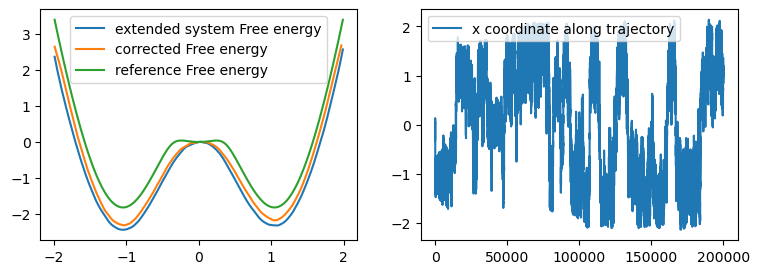

In [6]:
pot = TripleWellPotential(beta)
#--- perform the eABF simulation ---
eabf = eABF(pot, k=kappa, eXi_interval=[-2, 2])
(
    phys_traj,
    _,
    _,
    _,
    _,
    deF_grid, 
    _,
    _,
    dF_grid 
) = eabf.Simul(x_0,
               lambda_0,
               delta_t=dt,
               save=1,
               T=T,
               sum_deF_grid=None,
               hits_exi_grid=None,
               sum_lbd_xi_grid=None,
               hits_xi_grid=None,
               seed=seed)
#--- compute free energies, include the reference ---
eF_grid = eabf.integrate_deF(deF_grid)
F_grid = eabf.integrate_dF(dF_grid)
Fx_ref = np.zeros(len(eabf.eXi_grid_middles))
for i,x  in enumerate(eabf.eXi_grid_middles):
    Fx_ref[i] = pot.Fx(x)
Fx_ref = Fx_ref - (Fx_ref[len(eabf.Xi_grid_middles)//2] + Fx_ref[len(eabf.Xi_grid_middles)//2+1])/2
#--- plot the results ---
fig, (ax0, ax1)  = plt.subplots(1,2, figsize=(9,3)) 
ax0.plot(eabf.eXi_grid_middles, eF_grid, label='extended system Free energy')
ax0.plot(eabf.Xi_grid_middles[:-1], F_grid[:-1], label='corrected Free energy')
ax0.plot(eabf.Xi_grid_middles, Fx_ref, label='reference Free energy')
ax0.legend()
ax1.plot(phys_traj[:, 0], label='x coordinate along trajectory')
ax1.legend()
plt.show()

Once you managed to solve the problem mentioned in the previous code cell, you should see that the eABF free energy does not match perfectly with the reference one. In the next box we implement an infinite loop that generates an animation that you can stop once you see that the profiles match in a satisfactory way. The total trajectory is plotted every T steps.

Do not forget to look at the simulation parameters if it crashes or does something strange.

**Question 3.** What is the minimal number of time steps (in magnitude) eABF needs to converge to a "decent" free energy given $\kappa = 100$? For $\kappa=10$?  

In [7]:
beta = 4
kappa = 100
x_0 = np.array([0, 0])
lambda_0 = 0
dt = 0.005
T = 10000 
save = 1


/var/folders/1m/lqrr90rx2f397fjmvnd5lgd00000gn/T/ipykernel_60420/1568626182.py:143: RuntimeWarning: divide by zero encountered in log
  ln_biased_dens = np.log(hits_xi_grid / np.sum(hits_xi_grid)) # beware that this term can be ill defined
/Users/ryanlai/miniconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/var/folders/1m/lqrr90rx2f397fjmvnd5lgd00000gn/T/ipykernel_60420/1568626182.py:146: RuntimeWarning: invalid value encountered in scalar subtract
  dF_grid[1: -1] = np.array([0.5 * (ln_biased_dens[i+2] - ln_biased_dens[i]) for i in(range(len(ln_biased_dens)- 2))])
/var/folders/1m/lqrr90rx2f397fjmvnd5lgd00000gn/T/ipykernel_60420/1568626182.py:184: RuntimeWarning: invalid value encountered in scalar add
  F_grid[i] = np.sum(dF_grid[:i]) * self.xi_width + dF_grid[i] * self.xi_width/2
/Users/ryanlai/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWar

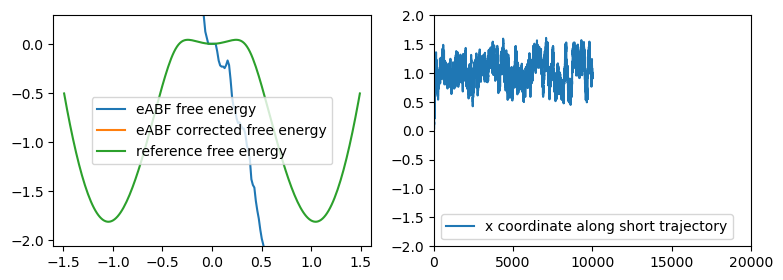

In [10]:
pot = TripleWellPotential(beta)
eabf = eABF(pot, k=kappa, eXi_interval=[-1.5, 1.5])

#--- prepare the plot for the animation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,3)) #create two axes
ln1, = ax1.plot([], [], label='eABF free energy')
ln2, = ax1.plot([], [], label='eABF corrected free energy')
ln3, = ax1.plot([], [], label='reference free energy')
ln4, = ax2.plot([], [], label='x coordinate along short trajectory')
# recompute reference free energy
Fx_ref = np.zeros(len(eabf.eXi_grid_middles))
for i,x  in enumerate(eabf.eXi_grid_middles):
    Fx_ref[i] = pot.Fx(x)
Fx_ref = Fx_ref - (Fx_ref[len(eabf.eXi_grid_middles)//2] + Fx_ref[len(eabf.eXi_grid_middles)//2+1])/2


#--- initialize parameters for simulation ---
n_splits = 10
hits_exi_grid = None
sum_deF_grid = None
sum_lbd_xi_grid = None
hits_xi_grid= None
Tot_traj = np.array([x_0])
phys_traj = Tot_traj.copy()
lambda_traj = np.array([lambda_0])
F_grid = np.zeros(eabf.Xi_grid_middles.shape)
eF_grid = np.zeros(eabf.eXi_grid_middles.shape)

#--- function which updates the profiles by running an eABF simulation ---
def update_val(frame):
    global hits_exi_grid
    global sum_deF_grid
    global Tot_traj
    global phys_traj
    global lambda_traj
    global F_grid
    global eF_grid
    global sum_lbd_xi_grid
    global hits_xi_grid
    global save
    (    
        phys_traj,
        lambda_traj,
        Xis,
        sum_deF_grid,
        hits_exi_grid,
        deF_grid, ## we are only interested in the mean force 
        sum_lbd_xi_grid,
        hits_xi_grid,
        dF_grid
    ) = eabf.Simul(Tot_traj[-1],
              lambda_traj[-1],
              delta_t=dt,  # change the time step here if needed
              T=T//n_splits,
              N_min=100,   
              save=save,
              sum_deF_grid=sum_deF_grid,
              hits_exi_grid=hits_exi_grid,
              sum_lbd_xi_grid=sum_lbd_xi_grid,
              hits_xi_grid=hits_xi_grid)
    Tot_traj = np.append(Tot_traj, phys_traj, axis=0)
    F_grid = eabf.integrate_dF(dF_grid)
    eF_grid = eabf.integrate_dF(deF_grid)
    ln1.set_data(eabf.eXi_grid_middles, eF_grid)
    ln2.set_data(eabf.Xi_grid_middles[:-1], F_grid[:-1])
    ln3.set_data(eabf.eXi_grid_middles, Fx_ref)
    ln4.set_data(range(len(Tot_traj[:,0]) ), Tot_traj[:,0]) 
    return ln1, ln2, ln3, ln4

def init():
    global save
    global Tot_traj
    global F_grid
    ax1.set_xlim(-1.6, 1.6) 
    ax1.set_ylim(np.min(Fx_ref) - 0.25, np.max(Fx_ref) + 0.25)
    ax1.legend()
    ax2.set_xlim(0, len(Tot_traj) + T // save)
    ax2.set_ylim(-2, 2)
    ax2.legend()
    return ln1, ln2, ln3, ln4

## For those using colab, switch repeat to False
ani = FuncAnimation(fig, update_val, frames=n_splits, init_func=init, blit=False, repeat=True)
ani.save('fig/eABF_animation.gif', writer='pillow', fps=1)

In [ ]:
## For those using colab  uncomment the following.
"""from IPython.display import HTML
HTML(ani.to_html5_video())  """

## Back to autoencoders

Now that you have seen that eABF indeed allows to recover (an approximation of) the free energy of the system and understood its dependance on key parameters such as $\kappa$, we can take a look at the free energy profiles corresponding to the reaction coordinates learned by the auto-encoders of Part 1. 

First we re-defines classes and important functions to evalute the models. Make sure the class in the cell below correspond strictly to the one you used when you saved your 'bestAE_model' at the end of Part 1 (otherwise it cannot be read properly).  

If everything is done correctly you should see at the end of the next cell exactly the same figure as at the end of Part 1.

In [20]:
#--- define the class of the AE identically to the one for the AE which was saved (could work nonetheless, though) ---
class SimpleAutoEncoder(torch.nn.Module):
    def __init__(self, input_dim,bottleneck_dim):
        """Initialise simplest autoencoder (input->bottleneck->ouput), with hyperbolic tangent activation function
       
        :param input_dim: int, Number of dimension of the input vectors
        :param bottleneck_dim: int, Number of dimension of the bottleneck
        """
        super(SimpleAutoEncoder, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, bottleneck_dim),
            torch.nn.Tanh()
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(bottleneck_dim, input_dim),
        )

    def forward(self, inp):
        encoded = self.encoder(inp)
        decoded = self.decoder(encoded)
        return decoded

class DeepAutoEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden_dims, bottleneck_dim):
        """Initialise auto encoder with hyperbolic tangent activation function
        you can uncomment certain lines in the encoder and decoder function to modify the architechture,
        make sure when you initialise the AE object that the list hidden_dims has the proper length corresponding
        to the architechture

        :param input_dim: int, Number of dimension of the input vectors
        :param hidden_dims: list, List of hidden layers
        :param bottleneck_dim: int, Number of dimension of the bottleneck
        """
        super(DeepAutoEncoder, self).__init__()
        # Input Linear function : input_dim --> hidden_dim
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            #torch.nn.Linear(hidden_dims[1], hidden_dims[2]),
            #torch.nn.Tanh(),
            #torch.nn.Linear(hidden_dims[2], hidden_dims[3]),
            #torch.nn.Tanh(),
            #torch.nn.Linear(hidden_dims[3], hidden_dims[4]),
            #torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[-1], bottleneck_dim),
            torch.nn.Tanh()
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(bottleneck_dim, hidden_dims[-1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[-1], hidden_dims[-2]),
            torch.nn.Tanh(),
            # torch.nn.Linear(hidden_dims[-2], hidden_dims[-3]),
            # torch.nn.Tanh(),
            # torch.nn.Linear(hidden_dims[-3], hidden_dims[-4]),
            # torch.nn.Tanh(),
            # torch.nn.Linear(hidden_dims[-4], hidden_dims[5]),
            # torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
            torch.nn.Tanh()
        )

    def forward(self, inp):
        # Input Linear function
        encoded = self.encoder(inp)
        decoded = self.decoder(encoded)
        return decoded

class AssymmetricAutoEncoder(torch.nn.Module):
    def __init__(self):
        super(AssymmetricAutoEncoder, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(2, 1),
            torch.nn.Tanh()
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(1, 2),
            torch.nn.Tanh(),
            torch.nn.Linear(2, 3),
            torch.nn.Tanh(),
            torch.nn.Linear(3, 2),
        )

    def forward(self, inp):
        encoded = self.encoder(inp)
        decoded = self.decoder(encoded)
        return decoded

def xi_ae(model, x):
    """Collective variable defined through an auto encoder model

    :param model: Neural network model build with pytorch,
    :param x: np.array, position, ndim = 2, shape = (1,1)

    :return: xi: np.array
    """
    model.eval()
    x = torch.tensor(x.astype('float32'))
    return model.encoder(x).detach().numpy()


## This new function we define here will be used of eABF simulations as we need the gradient of RC.
def grad_xi_ae(model, x):
    """Gradient of the collective variable defined through an auto encoder model

    :param model: Neural network model build with pytorch,
    :param x: np.array, position, ndim = 2, shape = (1,1)

    :return: grad_xi: np.array
    """
    model.eval()
    x = torch.tensor(x.astype('float32'))
    x.requires_grad_()
    enc = model.encoder(x)
    grad = torch.autograd.grad(enc, x)[0]
    return grad.detach().numpy()


<IPython.core.display.Javascript object>


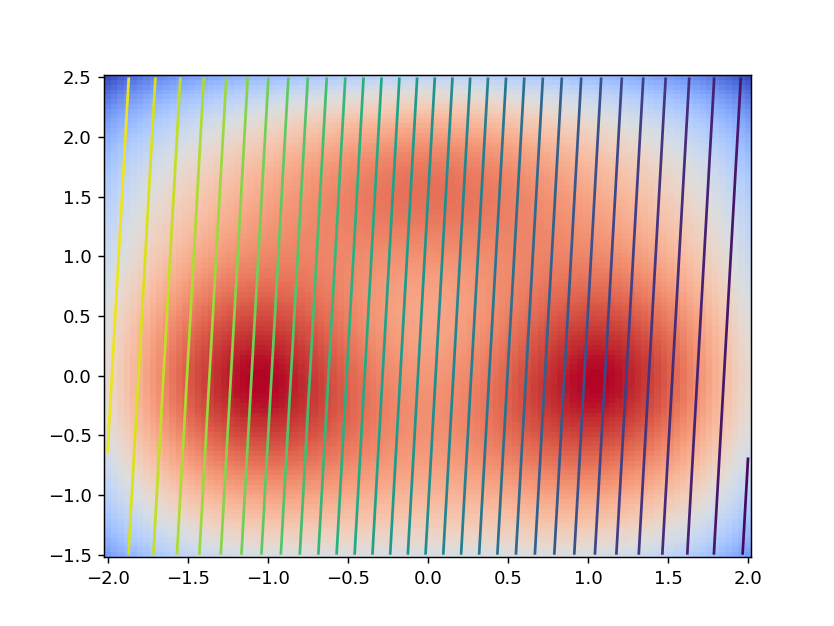

In [29]:
#--- print iso levels of our encoder to check whether it was loaded correctly ---
pot = TripleWellPotential(beta=4)

best_ae = torch.load('bestAE_model')
grid = np.linspace(-2,2,100)
x_plot = np.outer(grid, np.ones(100))
y_plot = np.outer(grid + 0.5, np.ones(100)).T
potential_on_grid = np.zeros([100, 100])
xi_best_ae_on_grid = np.zeros([100, 100])
for i in range(100):
    for j in range(100):
        x = np.array([grid[i], grid[j] + 0.5])
        potential_on_grid[i, j] = pot.V(x)
        xi_best_ae_on_grid[i,j] = xi_ae(best_ae, x)

plt.figure()
plt.pcolormesh(x_plot, y_plot, potential_on_grid, cmap='coolwarm_r',shading='auto')
plt.contour(x_plot, y_plot, xi_best_ae_on_grid, 40, cmap = 'viridis')

**Question 4.** Estimate how long should the eABF trajectories should be to converge the free enegy profiles associated with the AE. 

In [30]:
#--- define functions depending only on the positions for eABF (i.e. not taking the model as an argument) ---
def xi(x):
    return xi_ae(best_ae, x)

def grad_xi(x):
    return grad_xi_ae(best_ae, x)

#--- first evaluate the variation of xi on the relevant part of the potential ---
print('Minium and maximum value of the reaction coordinate on the grid used for plotting:')        
print([np.min(xi_best_ae_on_grid),np.max(xi_best_ae_on_grid)])

Minium and maximum value of the reaction coordinate on the grid used for plotting:
[-0.6472916603088379, 0.6298542022705078]


In [39]:
kappa = 100
beta = 4
x_0 = np.array([0, 0])
lambda_0 = 0
dt = 0.005
T = 10000  # total simulation time, to be split for one loop of visualisation
save = 1

<IPython.core.display.Javascript object>


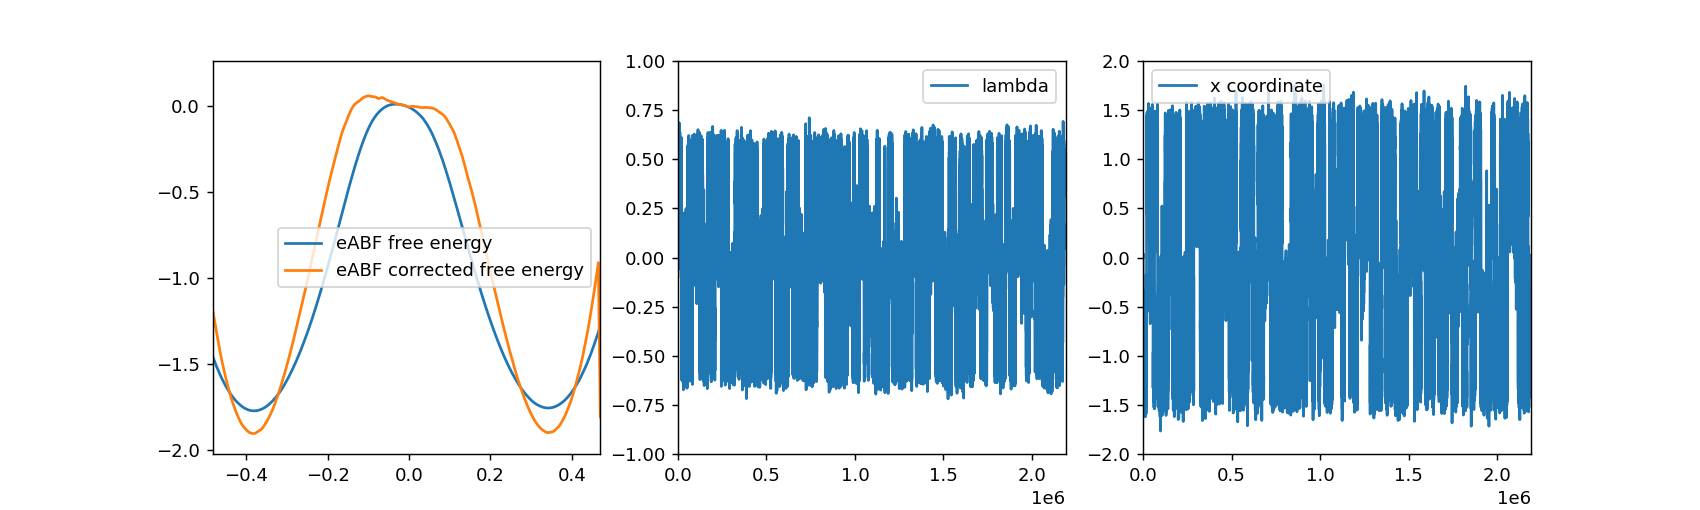

In [40]:
# Re-initialise potential and eabf class
pot = TripleWellPotential(beta)
factor = 0.75 # fraction of range of extended variable to explore before computing unbiased free energy
eabf = eABF(pot,
            k=kappa,
            Xi=xi,
            grad_Xi=grad_xi,
            eXi_interval=[factor*np.min(xi_best_ae_on_grid), factor*np.max(xi_best_ae_on_grid)]
           )

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,3)) # create three axes
ln1, = ax1.plot([], [], label='eABF free energy')
ln2, = ax1.plot([], [], label='eABF corrected free energy')

ln3, = ax2.plot([], [], label='lambda')
ln4, = ax3.plot([], [], label='x coordinate')

n_splits = 10
hits_xi_grid = None
sum_deF_grid = None
sum_lbd_xi_grid = None
hits_exi_grid = None
Tot_traj = np.array([x_0])
phys_traj = Tot_traj.copy()
Lambda_traj = np.array([lambda_0])
lambda_traj = np.array([lambda_0])
eF_grid = np.zeros(eabf.eXi_grid_middles.shape)
F_grid = np.zeros(eabf.Xi_grid_middles.shape)
xi_traj = np.array([[lambda_0]])


def update_val(frame):
    global hits_exi_grid
    global sum_deF_grid
    global Tot_traj
    global phys_traj
    global Lambda_traj
    global lambda_traj
    global eF_grid
    global F_grid
    global sum_lbd_xi_grid
    global hits_xi_grid
    global eabf
    (    
        phys_traj,
        lambda_traj,
        Xis,
        sum_deF_grid,
        hits_exi_grid,
        deF_grid, # we are only interested in the mean force 
        sum_lbd_xi_grid,
        hits_xi_grid,
        dF_grid
    ) = eabf.Simul(Tot_traj[-1],
              lambda_traj[-1],
              delta_t=dt,  
              T=T//n_splits,
              N_min=100,
              save=save,
              sum_deF_grid=sum_deF_grid,
              hits_exi_grid=hits_exi_grid,
              sum_lbd_xi_grid=sum_lbd_xi_grid,
              hits_xi_grid=hits_xi_grid)
    Tot_traj = np.append(Tot_traj, phys_traj, axis=0)
    Lambda_traj = np.append(Lambda_traj, lambda_traj, axis=0)
    eF_grid = eabf.integrate_deF(deF_grid)
    F_grid = eabf.integrate_dF(dF_grid)
    
def init():
    global Tot_traj
    global eF_grid
    global F_grid
    global eabf
    global save
    ax1.set_xlim(eabf.eXi_grid_middles[0], eabf.eXi_grid_middles[-1]) 
    ax1.set_ylim(np.min(eF_grid) - 0.25, np.max(eF_grid) + 0.25)
    ax1.legend()
    ax2.set_xlim(0, len(Tot_traj) * save + T)
    ax2.set_ylim(-1, 1)
    ax2.legend()
    ax3.set_xlim(0, len(Tot_traj) * save + T)
    ax3.set_ylim(-2, 2)
    ax3.legend()
    return ln1, ln2, ln3, ln4

def update(frame):
    update_val(frame)
    global hits_exi_grid
    global sum_deF_grid
    global Tot_traj
    global phys_traj
    global Lambda_traj
    global eF_grid
    global F_grid
    global sum_lbd_xi_grid
    global hits_xi_grid
    global eabf
    global save
    ln1.set_data(eabf.eXi_grid_middles, eF_grid)
    ln2.set_data(eabf.Xi_grid_middles, F_grid)
    x= save * np.arange(len(Lambda_traj))
    ln3.set_data(x, Lambda_traj)
    ln4.set_data(x, Tot_traj[:,0]) 
    return ln1, ln2, ln3, ln4

ani = FuncAnimation(fig, update, frames=n_splits, init_func=init, blit=False, repeat=True)

<IPython.core.display.Javascript object>


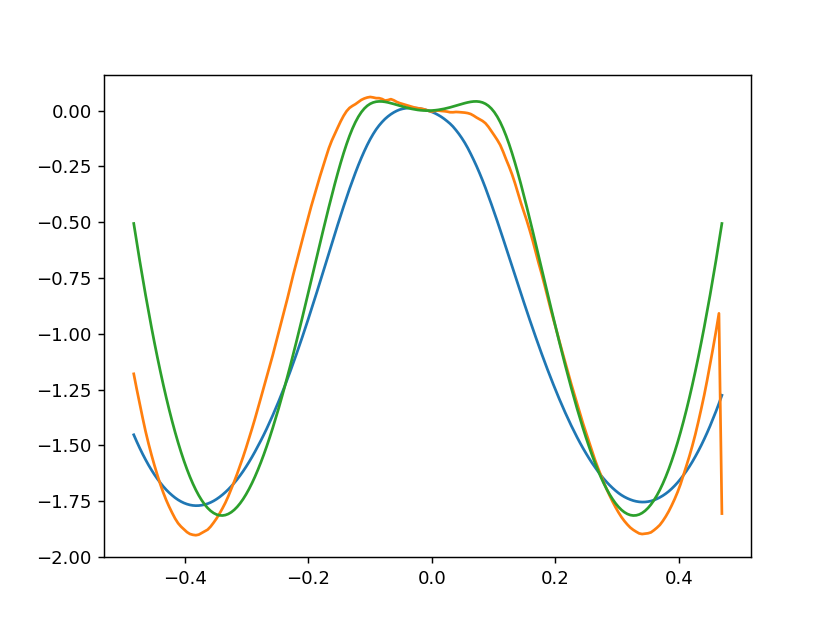

In [43]:
plt.figure()
plt.plot(eabf.eXi_grid_middles, eF_grid)
plt.plot(eabf.Xi_grid_middles, F_grid)
plt.plot(eabf.Xi_grid_middles, Fx_ref)